In [ ]:
!pip install kaggle

In [ ]:
! mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
from google.colab import files
files.upload()  # Upload your Kaggle API key

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"sonijugal","key":"3bd4f8c2b4d706330bfe1df271c7d2be"}'}

In [ ]:
!cp kaggle.json ~/.kaggle/

In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!mkdir plant-disease

In [ ]:
%cd plant-disease/

/content/plant-disease


In [ ]:
!kaggle datasets download -d rashikrahmanpritom/plant-disease-recognition-dataset

100% 1.24G/1.25G [00:07<00:00, 97.0MB/s]
100% 1.25G/1.25G [00:07<00:00, 176MB/s] 


In [ ]:
!unzip /content/plant-disease/plant-disease-recognition-dataset.zip

Archive:  /content/plant-disease/plant-disease-recognition-dataset.zip
  inflating: Test/Test/Healthy/8ddaa5a5caa5caa8.jpg  
  inflating: Test/Test/Healthy/8ddaac1bd6c8cd0a.jpg  
  inflating: Test/Test/Healthy/8ddd5ec1c0de38c4.jpg  
  inflating: Test/Test/Healthy/8def3f60308ab41b.jpg  
  inflating: Test/Test/Healthy/8def4d91382175c3.jpg  
  inflating: Test/Test/Healthy/8df452e2e38c0b6e.jpg  
  inflating: Test/Test/Healthy/8dfae9d78cc32089.jpg  
  inflating: Test/Test/Healthy/8e3dbccdfe08c850.jpg  
  inflating: Test/Test/Healthy/8e68163c62dc57d5.jpg  
  inflating: Test/Test/Healthy/8e6a823cce9ff40c.jpg  
  inflating: Test/Test/Healthy/8e77857194a59a87.jpg  
  inflating: Test/Test/Healthy/8e79802b3fb770c8.jpg  
  inflating: Test/Test/Healthy/8e7986d1ecd36445.jpg  
  inflating: Test/Test/Healthy/8e7e70a6878c1c79.jpg  
  inflating: Test/Test/Healthy/8e82b1a51bd11afe.jpg  
  inflating: Test/Test/Healthy/8e8470687be37378.jpg  
  inflating: Test/Test/Healthy/8e858c8397706b7b.jpg  
  inflating

In [ ]:
# importing libraries
import keras
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential, save_model, load_model
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Dropout, Flatten, Dense
import numpy as np
from keras.callbacks import TensorBoard
import time
import matplotlib.pyplot as plt
import datetime
import cv2
import os
import tensorflow as tf
import tensorflow.keras
import cv2

In [ ]:
img_width, img_height = 80,80
train_data_dir = '/content/plant-disease/Train/Train'
validation_data_dir = '/content/plant-disease/Test/Test'
eval_data_dir = '/content/plant-disease/Validation/Validation'


nb_train_samples = 1322
nb_validation_samples = 150
nb_eval_samples = 60
epochs = 100
batch_size = 128
num_of_class = 3

In [ ]:
train_datagen = ImageDataGenerator( #Image Augmentation
                rescale = 1. / 255,
                shear_range = 0.25,
                zoom_range = 0.25,
                rotation_range=10)

test_datagen = ImageDataGenerator(rescale = 1. / 255) #Image Augmentation



train_generator = train_datagen.flow_from_directory(train_data_dir,
                                                    target_size =(img_width, img_height),
                                                    batch_size = batch_size, class_mode ='categorical',color_mode='rgb', #grayscale
                                                    shuffle=False)

validation_generator = test_datagen.flow_from_directory(validation_data_dir,
                                                        target_size =(img_width, img_height),
                                                        batch_size = batch_size, class_mode ='categorical',color_mode='rgb', #grayscale
                                                        shuffle=False)

eval_generator = test_datagen.flow_from_directory(eval_data_dir,
                                                  target_size =(img_width, img_height),
                                                  batch_size = batch_size, class_mode ='categorical',color_mode='rgb', #grayscale
                                                  shuffle=False)


Found 1322 images belonging to 3 classes.
Found 150 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


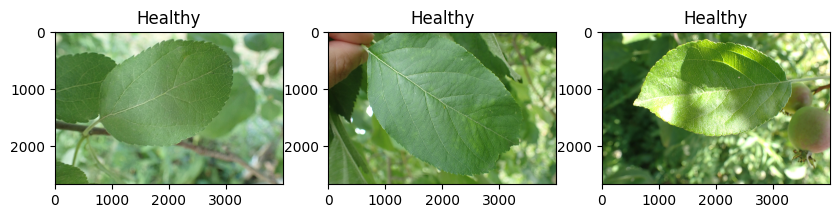

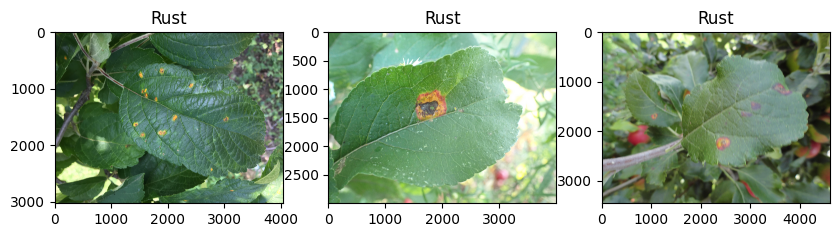

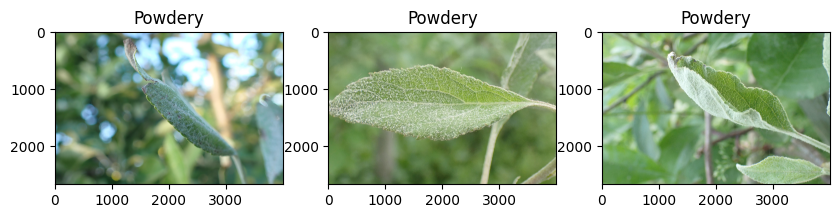

In [ ]:
import random

def rescale_and_plot_images(image_files,class_name):
    for idx, img_path in enumerate(image_files):
        plt.subplot(1, 3, idx + 1)
        img = plt.imread(img_path)
        plt.imshow(img, cmap = 'gray')
        plt.title(class_name)

def plot_images(path, class_name):
    image_paths = []
    class_name_path = os.path.join(path, class_name)
    image_paths = [os.path.join(class_name_path, img_png) for img_png in random.sample(os.listdir(class_name_path), 3)]

    plt.figure(figsize = (10, 25))
    rescale_and_plot_images(image_paths,class_name)


plot_images(train_data_dir, 'Healthy')
plot_images(train_data_dir, 'Rust')
plot_images(train_data_dir, 'Powdery')

In [ ]:
input_shape = (img_width, img_height, 3)
model3 = Sequential()

model3.add(Conv2D(32, (3,3), input_shape=input_shape, activation='relu',data_format='channels_last'))
model3.add(MaxPooling2D((2,2), strides=(1,1), padding='same'),)

model3.add(Conv2D(64, (3,3), activation='relu'),)
model3.add(MaxPooling2D((2,2), strides=(1,1), padding='same'),)

model3.add(Conv2D(128, (3,3), activation='relu'),)
model3.add(MaxPooling2D((2,2), strides=(1,1), padding='same'),)
# model3.add(Dropout(0.15))

model3.add(Flatten())

model3.add(Dense(128, activation='relu'))
model3.add(Dense(64, activation='relu'))

model3.add(Dropout(0.5))
model3.add(Dense(num_of_class, activation='softmax'))


In [ ]:
model3.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 78, 78, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 78, 78, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 76, 76, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 76, 76, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 74, 74, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 74, 74, 128)      0

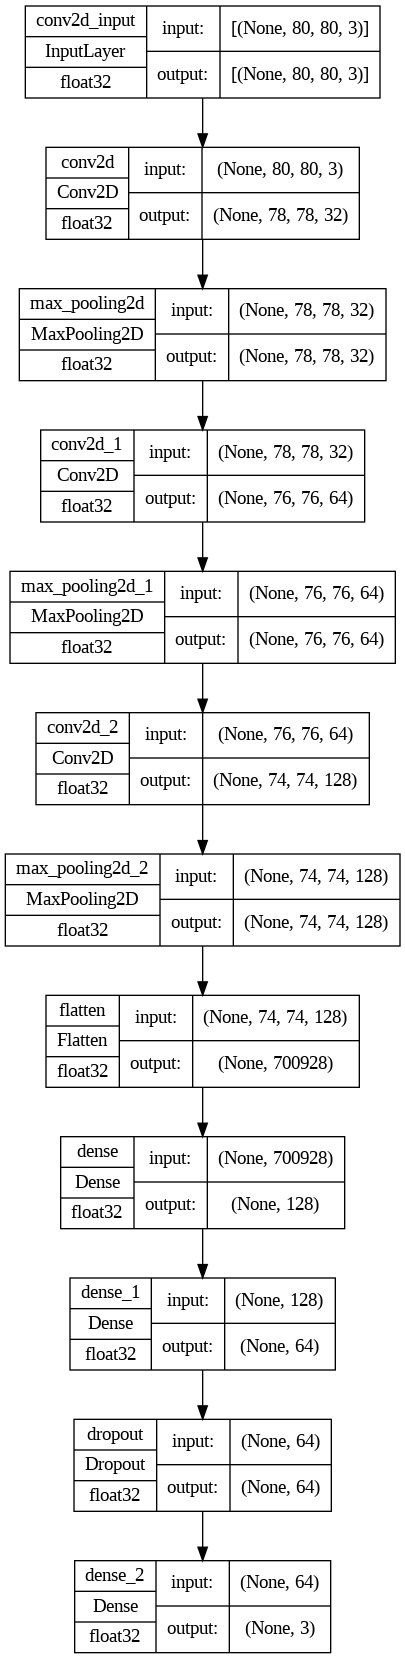

In [ ]:
keras.utils.plot_model(
    model3,
    to_file="model.png",
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=False,
    dpi=96,
)

In [ ]:
model3.compile(loss ='categorical_crossentropy',
                     optimizer ='rmsprop',
                   metrics =['accuracy'])

In [ ]:
H = model3.fit(
    train_generator,
    steps_per_epoch=nb_train_samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=nb_validation_samples // batch_size
)

Epoch 1/100
10/10 [==============================] - 362s 35s/step - loss: 36.2423 - accuracy: 0.2111 - val_loss: 1.0749 - val_accuracy: 0.3906
Epoch 2/100
10/10 [==============================] - 310s 30s/step - loss: 1.2741 - accuracy: 0.2663 - val_loss: 1.0931 - val_accuracy: 0.3281
Epoch 3/100
10/10 [==============================] - 299s 29s/step - loss: 1.1658 - accuracy: 0.3032 - val_loss: 1.2663 - val_accuracy: 0.2188
Epoch 4/100
10/10 [==============================] - 307s 30s/step - loss: 1.1982 - accuracy: 0.1583 - val_loss: 1.0965 - val_accuracy: 0.5000
Epoch 5/100
10/10 [==============================] - 301s 32s/step - loss: 1.5826 - accuracy: 0.2312 - val_loss: 1.0914 - val_accuracy: 0.5625
Epoch 6/100
10/10 [==============================] - 308s 30s/step - loss: 1.6290 - accuracy: 0.3509 - val_loss: 3.0584 - val_accuracy: 0.3906
Epoch 7/100
10/10 [==============================] - 293s 28s/step - loss: 1.3490 - accuracy: 0.2236 - val_loss: 1.0988 - val_accuracy: 0.453

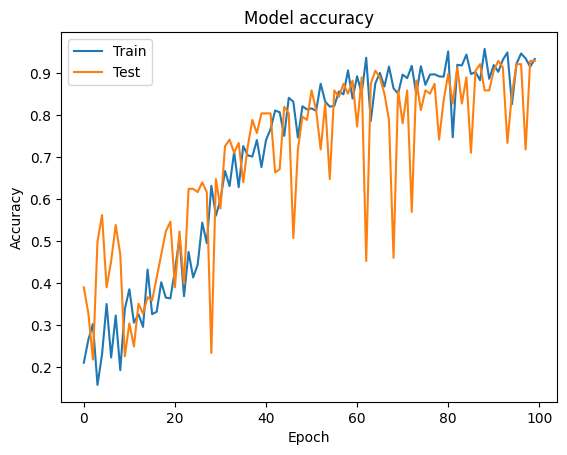

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
fig, ax = plt.subplots(1,1)
plt.plot(H.history["accuracy"])
plt.plot(H.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

fig.savefig('./'+'model1_train_test_accuracy.jpeg',dpi=93)

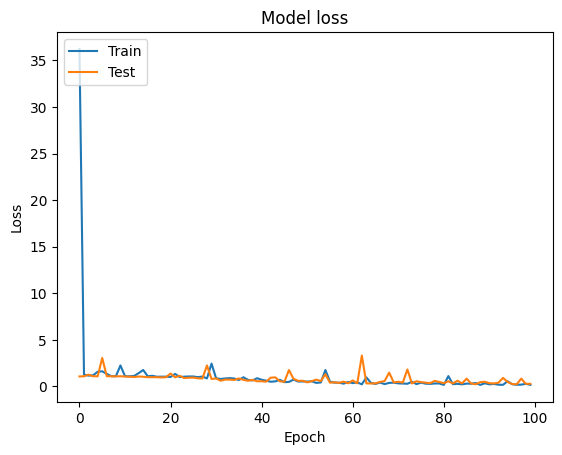

In [ ]:
# Plot training & validation loss values
fig, ax = plt.subplots(1,1)
plt.plot(H.history['loss'])
plt.plot(H.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()
fig.savefig('./'+'model1_train_test_los.jpeg',dpi=93)

In [ ]:
NAME="plant-disease-recognition"
model3.save('./'+NAME+'.hdf5')

1/1 [==============================] - 7s 7s/step
Classification Report
              precision    recall  f1-score   support

     Healthy       0.86      0.90      0.88        20
     Powdery       0.90      0.95      0.93        20
        Rust       1.00      0.90      0.95        20

    accuracy                           0.92        60
   macro avg       0.92      0.92      0.92        60
weighted avg       0.92      0.92      0.92        60



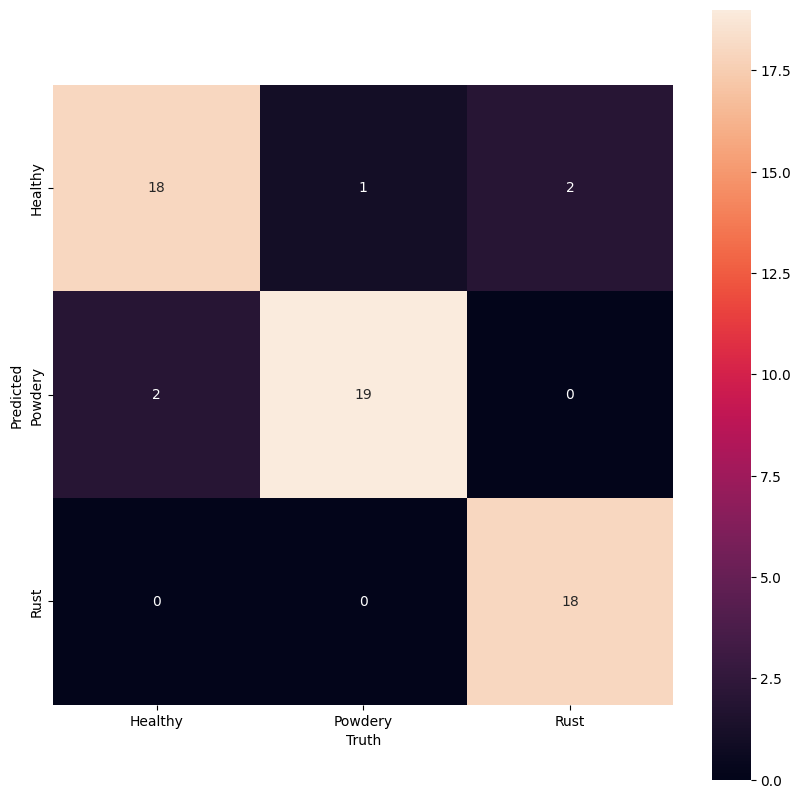

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
target_names=['Healthy','Powdery','Rust']

Y_pred = model3.predict(eval_generator, nb_eval_samples // batch_size+1)
y_pred = np.argmax(Y_pred, axis=1)


plt.figure(figsize=(10,10))
cm = confusion_matrix(eval_generator.classes, y_pred)
_=sns.heatmap(cm.T, annot=True, fmt='d', cbar=True, square=True, xticklabels=target_names,
             yticklabels=target_names)
plt.xlabel('Truth')
plt.ylabel('Predicted')
plt.savefig('./'+'confusion_matrix_onEval.jpeg',dpi=93)

print('Classification Report')
report = classification_report(eval_generator.classes, y_pred, target_names=target_names)
print(report)

2/2 [==============================] - 14s 595ms/step
Classification Report
              precision    recall  f1-score   support

     Healthy       0.86      0.98      0.92        50
     Powdery       0.96      0.88      0.92        50
        Rust       0.98      0.92      0.95        50

    accuracy                           0.93       150
   macro avg       0.93      0.93      0.93       150
weighted avg       0.93      0.93      0.93       150



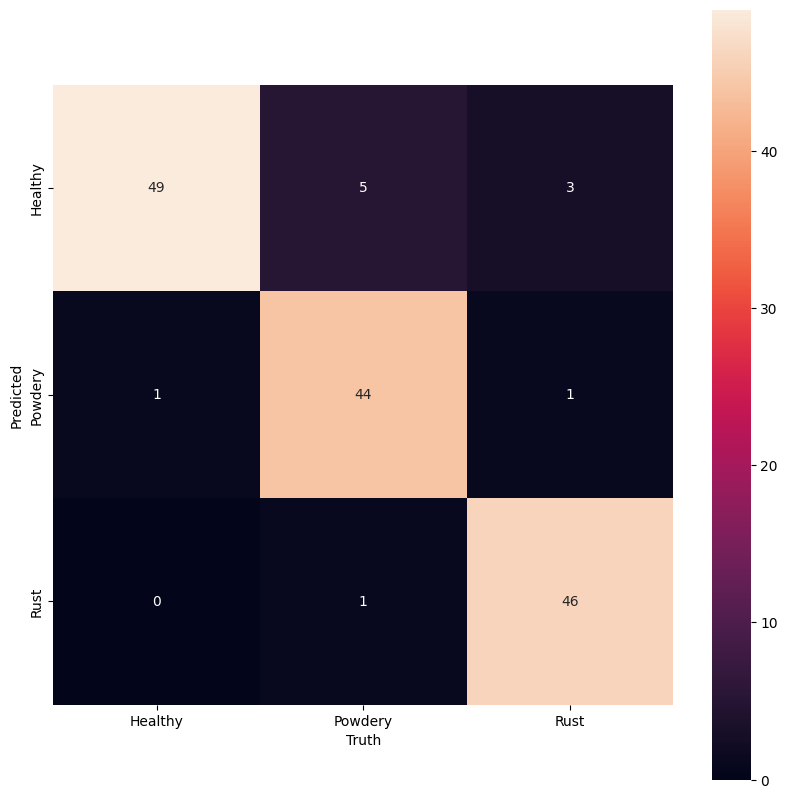

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report


Y_pred = model3.predict(validation_generator, nb_validation_samples // batch_size+1)
y_pred = np.argmax(Y_pred, axis=1)


plt.figure(figsize=(10,10))
cm = confusion_matrix(validation_generator.classes, y_pred)
_=sns.heatmap(cm.T, annot=True, fmt='d', cbar=True, square=True, xticklabels=target_names,
             yticklabels=target_names)
plt.xlabel('Truth')
plt.ylabel('Predicted')
plt.savefig('./'+'confusion_matrix_onValidation.jpeg',dpi=93)

print('Classification Report')
report = classification_report(validation_generator.classes, y_pred, target_names=target_names)
print(report)